In [2]:

import os

drive_path = '/content/drive/MyDrive/reddit' # Updated path to look inside the nested 'ppi' directory

# Check if the directory exists
if not os.path.exists(drive_path):
    print(f"The directory '{drive_path}' does not exist.")
else:
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        item_path = os.path.join(drive_path, item)
        if os.path.isdir(item_path):
            print(f"[DIR] {item}")
        else:
            print(f"[FILE] {item}")

Contents of '/content/drive/MyDrive/reddit':
[FILE] reddit-feats.npy
[FILE] reddit-G.json
[FILE] reddit-walks.txt
[FILE] reddit-adjlist.txt
[FILE] reddit-G_full.json
[FILE] reddit-class_map.json
[FILE] reddit-id_map.json


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import json
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


### Evaluation of Unsupervised Models (Link Prediction)

In [18]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Number of evaluation edges
EVAL_BATCH_SIZE = 8192 # Larger batch size for evaluation

print("\n--- Evaluating Unsupervised GraphSAGE_Mean ---")
unsupervised_model_mean.eval()
with torch.no_grad():
    embeddings_mean = unsupervised_model_mean(features, adj)

    # Sample edges for evaluation
    eval_positive_edges_mean, eval_negative_edges_mean = sample_edges(
        adj, num_nodes, EVAL_BATCH_SIZE // 2, EVAL_BATCH_SIZE // 2
    )

    # Prepare indices and embeddings for evaluation edges
    eval_pos_u_indices_mean = torch.tensor([p[0] for p in eval_positive_edges_mean], device=device, dtype=torch.long)
    eval_pos_v_indices_mean = torch.tensor([p[1] for p in eval_positive_edges_mean], device=device, dtype=torch.long)
    eval_neg_u_indices_mean = torch.tensor([n[0] for n in eval_negative_edges_mean], device=device, dtype=torch.long)
    eval_neg_v_indices_mean = torch.tensor([n[1] for n in eval_negative_edges_mean], device=device, dtype=torch.long)

    eval_pos_u_emb_mean = embeddings_mean[eval_pos_u_indices_mean]
    eval_pos_v_emb_mean = embeddings_mean[eval_pos_v_indices_mean]
    eval_neg_u_emb_mean = embeddings_mean[eval_neg_u_indices_mean]
    eval_neg_v_emb_mean = embeddings_mean[eval_neg_v_indices_mean]

    # Calculate scores
    eval_pos_scores_mean = torch.sum(eval_pos_u_emb_mean * eval_pos_v_emb_mean, dim=1)
    eval_neg_scores_mean = torch.sum(eval_neg_u_emb_mean * eval_neg_v_emb_mean, dim=1)

    # Combine scores and create true labels
    eval_all_scores_mean = torch.cat([eval_pos_scores_mean, eval_neg_scores_mean]).cpu().numpy()
    eval_labels_mean = torch.cat([
        torch.ones_like(eval_pos_scores_mean, dtype=torch.float32),
        torch.zeros_like(eval_neg_scores_mean, dtype=torch.float32)
    ]).cpu().numpy()

    # Calculate AUC-ROC and Average Precision
    auc_roc_mean = roc_auc_score(eval_labels_mean, eval_all_scores_mean)
    ap_mean = average_precision_score(eval_labels_mean, eval_all_scores_mean)

    print(f"GraphSAGE_Mean Unsupervised - AUC-ROC: {auc_roc_mean:.4f}")
    print(f"GraphSAGE_Mean Unsupervised - Average Precision: {ap_mean:.4f}")


print("\n--- Evaluating Unsupervised GraphSAGE_GCN ---")
unsupervised_model_gcn.eval()
with torch.no_grad():
    embeddings_gcn = unsupervised_model_gcn(features, adj)

    # Sample edges for evaluation
    eval_positive_edges_gcn, eval_negative_edges_gcn = sample_edges(
        adj, num_nodes, EVAL_BATCH_SIZE // 2, EVAL_BATCH_SIZE // 2
    )

    # Prepare indices and embeddings for evaluation edges
    eval_pos_u_indices_gcn = torch.tensor([p[0] for p in eval_positive_edges_gcn], device=device, dtype=torch.long)
    eval_pos_v_indices_gcn = torch.tensor([p[1] for p in eval_positive_edges_gcn], device=device, dtype=torch.long)
    eval_neg_u_indices_gcn = torch.tensor([n[0] for n in eval_negative_edges_gcn], device=device, dtype=torch.long)
    eval_neg_v_indices_gcn = torch.tensor([n[1] for n in eval_negative_edges_gcn], device=device, dtype=torch.long)

    eval_pos_u_emb_gcn = embeddings_gcn[eval_pos_u_indices_gcn]
    eval_pos_v_emb_gcn = embeddings_gcn[eval_pos_v_indices_gcn]
    eval_neg_u_emb_gcn = embeddings_gcn[eval_neg_u_indices_gcn]
    eval_neg_v_emb_gcn = embeddings_gcn[eval_neg_v_indices_gcn]

    # Calculate scores
    eval_pos_scores_gcn = torch.sum(eval_pos_u_emb_gcn * eval_pos_v_emb_gcn, dim=1)
    eval_neg_scores_gcn = torch.sum(eval_neg_u_emb_gcn * eval_neg_v_emb_gcn, dim=1)

    # Combine scores and create true labels
    eval_all_scores_gcn = torch.cat([eval_pos_scores_gcn, eval_neg_scores_gcn]).cpu().numpy()
    eval_labels_gcn = torch.cat([
        torch.ones_like(eval_pos_scores_gcn, dtype=torch.float32),
        torch.zeros_like(eval_neg_scores_gcn, dtype=torch.float32)
    ]).cpu().numpy()

    # Calculate AUC-ROC and Average Precision
    auc_roc_gcn = roc_auc_score(eval_labels_gcn, eval_all_scores_gcn)
    ap_gcn = average_precision_score(eval_labels_gcn, eval_all_scores_gcn)

    print(f"GraphSAGE_GCN Unsupervised - AUC-ROC: {auc_roc_gcn:.4f}")
    print(f"GraphSAGE_GCN Unsupervised - Average Precision: {ap_gcn:.4f}")


--- Evaluating Unsupervised GraphSAGE_Mean ---
GraphSAGE_Mean Unsupervised - AUC-ROC: 0.5541
GraphSAGE_Mean Unsupervised - Average Precision: 0.5165

--- Evaluating Unsupervised GraphSAGE_GCN ---
GraphSAGE_GCN Unsupervised - AUC-ROC: 0.5577
GraphSAGE_GCN Unsupervised - Average Precision: 0.5315


### Unsupervised Learning Implementation

In [15]:
import random

def sample_edges(adj_matrix_sparse, num_nodes, num_positive_samples, num_negative_samples):
    """
    Samples positive (existing) and negative (non-existing) edges from a sparse adjacency matrix.
    """
    adj_matrix_sparse = adj_matrix_sparse.coalesce() # Ensure unique indices if not already

    # Get all existing edges as tuples (u, v)
    rows = adj_matrix_sparse.indices()[0].cpu().numpy()
    cols = adj_matrix_sparse.indices()[1].cpu().numpy()

    existing_edges = set()
    for r, c in zip(rows, cols):
        if r != c: # No self-loops
            existing_edges.add(tuple(sorted((r, c)))) # Store canonical form (min, max)

    # Sample positive edges
    positive_edges = random.sample(list(existing_edges), min(num_positive_samples, len(existing_edges)))

    # Sample negative edges
    negative_edges = []
    num_sampled_neg = 0
    max_attempts = num_negative_samples * 10 # Avoid infinite loops for dense graphs
    attempts = 0

    while num_sampled_neg < num_negative_samples and attempts < max_attempts:
        u, v = random.randint(0, num_nodes - 1), random.randint(0, num_nodes - 1)
        if u != v and tuple(sorted((u, v))) not in existing_edges:
            negative_edges.append((u, v))
            existing_edges.add(tuple(sorted((u, v)))) # Add to avoid resampling same negative edge in this batch
            num_sampled_neg += 1
        attempts += 1

    if num_sampled_neg < num_negative_samples:
        print(f"Warning: Only {num_sampled_neg} negative samples found out of {num_negative_samples} requested.")

    return positive_edges, negative_edges

# Initialize models for unsupervised learning (link prediction objective)
# The out_dim now represents the embedding dimension
unsupervised_embedding_dim = 128

unsupervised_model_mean = GraphSAGE_Mean(
    features.shape[1],
    128,
    unsupervised_embedding_dim # Output embeddings of this dimension
).to(device)

unsupervised_model_gcn = GraphSAGE_GCN(
    features.shape[1],
    128,
    unsupervised_embedding_dim # Output embeddings of this dimension
).to(device)

print("Unsupervised models initialized with embedding dimension:", unsupervised_embedding_dim)

Unsupervised models initialized with embedding dimension: 128



--- Training Unsupervised GraphSAGE_Mean (Link Prediction) ---
Epoch: 0, Unsupervised Mean Loss: 33.2283
Epoch: 1, Unsupervised Mean Loss: 16.4840
Epoch: 2, Unsupervised Mean Loss: 13.9719
Epoch: 3, Unsupervised Mean Loss: 7.2085
Epoch: 4, Unsupervised Mean Loss: 3.5487
Epoch: 5, Unsupervised Mean Loss: 4.0468
Epoch: 6, Unsupervised Mean Loss: 5.5230
Epoch: 7, Unsupervised Mean Loss: 2.6239
Epoch: 8, Unsupervised Mean Loss: 2.3703
Epoch: 9, Unsupervised Mean Loss: 2.4988
Epoch: 10, Unsupervised Mean Loss: 1.7214
Epoch: 11, Unsupervised Mean Loss: 1.6865
Epoch: 12, Unsupervised Mean Loss: 1.4768
Epoch: 13, Unsupervised Mean Loss: 1.5191
Epoch: 14, Unsupervised Mean Loss: 1.7310
Epoch: 15, Unsupervised Mean Loss: 1.2718
Epoch: 16, Unsupervised Mean Loss: 1.4120
Epoch: 17, Unsupervised Mean Loss: 1.0953
Epoch: 18, Unsupervised Mean Loss: 1.0542
Epoch: 19, Unsupervised Mean Loss: 1.1821


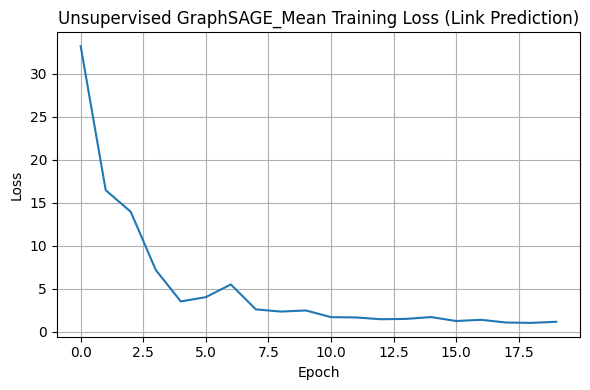

In [16]:
optimizer_unsupervised_mean = torch.optim.Adam(unsupervised_model_mean.parameters(), lr=0.001)

loss_history_unsupervised_mean = []

num_epochs_unsupervised = 20
BATCH_SIZE_UNSUPERVISED = 4096 # Number of edges to sample per epoch for loss calculation

print("\n--- Training Unsupervised GraphSAGE_Mean (Link Prediction) ---")
for epoch in range(num_epochs_unsupervised):
    unsupervised_model_mean.train()

    # Get node embeddings (transductive, so compute for all nodes)
    embeddings = unsupervised_model_mean(features, adj)

    # Sample positive and negative edges
    positive_edges, negative_edges = sample_edges(adj, num_nodes, BATCH_SIZE_UNSUPERVISED // 2, BATCH_SIZE_UNSUPERVISED // 2)

    if not positive_edges or not negative_edges:
        print(f"Epoch {epoch}: Not enough positive or negative edges to sample. Skipping epoch.")
        loss_history_unsupervised_mean.append(loss_history_unsupervised_mean[-1] if loss_history_unsupervised_mean else 0.0)
        continue

    # Prepare indices for selected edges
    pos_u_indices = torch.tensor([p[0] for p in positive_edges], device=device, dtype=torch.long)
    pos_v_indices = torch.tensor([p[1] for p in positive_edges], device=device, dtype=torch.long)
    neg_u_indices = torch.tensor([n[0] for n in negative_edges], device=device, dtype=torch.long)
    neg_v_indices = torch.tensor([n[1] for n in negative_edges], device=device, dtype=torch.long)

    # Get embeddings for the sampled nodes
    pos_u_emb = embeddings[pos_u_indices]
    pos_v_emb = embeddings[pos_v_indices]
    neg_u_emb = embeddings[neg_u_indices]
    neg_v_emb = embeddings[neg_v_indices]

    # Calculate scores (dot product similarity)
    pos_scores = torch.sum(pos_u_emb * pos_v_emb, dim=1)
    neg_scores = torch.sum(neg_u_emb * neg_v_emb, dim=1)

    # Combine scores and create target labels
    all_scores = torch.cat([pos_scores, neg_scores])
    labels_lp = torch.cat([
        torch.ones_like(pos_scores, dtype=torch.float32),
        torch.zeros_like(neg_scores, dtype=torch.float32)
    ])

    # Calculate loss
    loss_unsupervised_mean = F.binary_cross_entropy_with_logits(all_scores, labels_lp)

    optimizer_unsupervised_mean.zero_grad()
    loss_unsupervised_mean.backward()
    optimizer_unsupervised_mean.step()

    loss_history_unsupervised_mean.append(loss_unsupervised_mean.item())

    print(f"Epoch: {epoch}, Unsupervised Mean Loss: {loss_unsupervised_mean.item():.4f}")

# Plotting unsupervised training loss
plt.figure(figsize=(6, 4))
plt.plot(loss_history_unsupervised_mean)
plt.title('Unsupervised GraphSAGE_Mean Training Loss (Link Prediction)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()


--- Training Unsupervised GraphSAGE_GCN (Link Prediction) ---
Epoch: 0, Unsupervised GCN Loss: 35.6379
Epoch: 1, Unsupervised GCN Loss: 26.1994
Epoch: 2, Unsupervised GCN Loss: 18.6050
Epoch: 3, Unsupervised GCN Loss: 13.5236
Epoch: 4, Unsupervised GCN Loss: 9.2051
Epoch: 5, Unsupervised GCN Loss: 6.2677
Epoch: 6, Unsupervised GCN Loss: 4.1153
Epoch: 7, Unsupervised GCN Loss: 2.7302
Epoch: 8, Unsupervised GCN Loss: 1.9169
Epoch: 9, Unsupervised GCN Loss: 1.5998
Epoch: 10, Unsupervised GCN Loss: 1.4676
Epoch: 11, Unsupervised GCN Loss: 1.4213
Epoch: 12, Unsupervised GCN Loss: 1.4289
Epoch: 13, Unsupervised GCN Loss: 1.3940
Epoch: 14, Unsupervised GCN Loss: 1.2789
Epoch: 15, Unsupervised GCN Loss: 1.1824
Epoch: 16, Unsupervised GCN Loss: 1.0948
Epoch: 17, Unsupervised GCN Loss: 1.0050
Epoch: 18, Unsupervised GCN Loss: 0.9437
Epoch: 19, Unsupervised GCN Loss: 0.9902


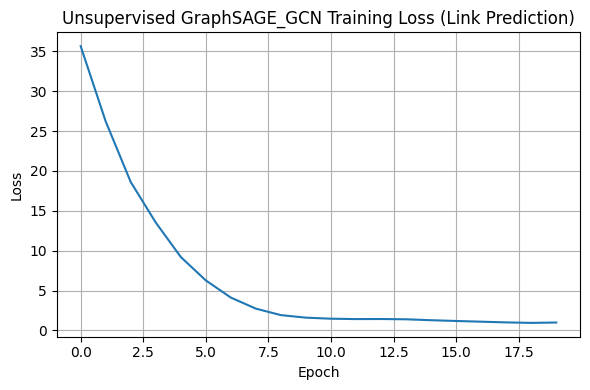

In [17]:
optimizer_unsupervised_gcn = torch.optim.Adam(unsupervised_model_gcn.parameters(), lr=0.001)

loss_history_unsupervised_gcn = []

print("\n--- Training Unsupervised GraphSAGE_GCN (Link Prediction) ---")
for epoch in range(num_epochs_unsupervised):
    unsupervised_model_gcn.train()

    # Get node embeddings (transductive, so compute for all nodes)
    embeddings = unsupervised_model_gcn(features, adj)

    # Sample positive and negative edges
    positive_edges, negative_edges = sample_edges(adj, num_nodes, BATCH_SIZE_UNSUPERVISED // 2, BATCH_SIZE_UNSUPERVISED // 2)

    if not positive_edges or not negative_edges:
        print(f"Epoch {epoch}: Not enough positive or negative edges to sample. Skipping epoch.")
        loss_history_unsupervised_gcn.append(loss_history_unsupervised_gcn[-1] if loss_history_unsupervised_gcn else 0.0)
        continue

    # Prepare indices for selected edges
    pos_u_indices = torch.tensor([p[0] for p in positive_edges], device=device, dtype=torch.long)
    pos_v_indices = torch.tensor([p[1] for p in positive_edges], device=device, dtype=torch.long)
    neg_u_indices = torch.tensor([n[0] for n in negative_edges], device=device, dtype=torch.long)
    neg_v_indices = torch.tensor([n[1] for n in negative_edges], device=device, dtype=torch.long)

    # Get embeddings for the sampled nodes
    pos_u_emb = embeddings[pos_u_indices]
    pos_v_emb = embeddings[pos_v_indices]
    neg_u_emb = embeddings[neg_u_indices]
    neg_v_emb = embeddings[neg_v_indices]

    # Calculate scores (dot product similarity)
    pos_scores = torch.sum(pos_u_emb * pos_v_emb, dim=1)
    neg_scores = torch.sum(neg_u_emb * neg_v_emb, dim=1)

    # Combine scores and create target labels
    all_scores = torch.cat([pos_scores, neg_scores])
    labels_lp = torch.cat([
        torch.ones_like(pos_scores, dtype=torch.float32),
        torch.zeros_like(neg_scores, dtype=torch.float32)
    ])

    # Calculate loss
    loss_unsupervised_gcn = F.binary_cross_entropy_with_logits(all_scores, labels_lp)

    optimizer_unsupervised_gcn.zero_grad()
    loss_unsupervised_gcn.backward()
    optimizer_unsupervised_gcn.step()

    loss_history_unsupervised_gcn.append(loss_unsupervised_gcn.item())

    print(f"Epoch: {epoch}, Unsupervised GCN Loss: {loss_unsupervised_gcn.item():.4f}")

# Plotting unsupervised training loss
plt.figure(figsize=(6, 4))
plt.plot(loss_history_unsupervised_gcn)
plt.title('Unsupervised GraphSAGE_GCN Training Loss (Link Prediction)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
data_dir = "/content/drive/MyDrive/reddit"

features = np.load(f"{data_dir}/reddit-feats.npy")

with open(f"{data_dir}/reddit-G.json") as f:
    graph = json.load(f)

with open(f"{data_dir}/reddit-id_map.json") as f:
    id_map = json.load(f)

with open(f"{data_dir}/reddit-class_map.json") as f:
    class_map = json.load(f)

print("features:", features.shape)

features: (232965, 602)


In [5]:
from scipy.sparse import lil_matrix

num_nodes = len(id_map)

adj = lil_matrix((num_nodes, num_nodes))

for edge in graph["links"]:
    src = edge["source"]
    dst = edge["target"]

    adj[src, dst] = 1
    adj[dst, src] = 1

print("Adj built")

Adj built


In [6]:
adj = adj.tocsr()

deg = np.array(adj.sum(1)).flatten()
deg[deg == 0] = 1

D_inv = 1.0 / deg
adj = adj.multiply(D_inv[:, None])

In [7]:
num_classes = max(class_map.values()) + 1

labels = np.zeros((num_nodes, num_classes))

for node, label in class_map.items():
    labels[id_map[node]] = label

print("labels:", labels.shape)

labels: (232965, 41)


In [8]:
features = torch.tensor(features, dtype=torch.float32).to(device)
labels = torch.tensor(labels, dtype=torch.float32).to(device)

# Convert scipy sparse matrix to torch sparse tensor to save memory
coo = adj.tocoo()
indices = torch.tensor(np.vstack((coo.row, coo.col)), dtype=torch.int64)
values = torch.tensor(coo.data, dtype=torch.float32)
shape = torch.Size(coo.shape)

adj = torch.sparse_coo_tensor(indices, values, shape, dtype=torch.float32).to(device)

In [9]:
class GraphSAGE_Mean(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        self.fc1 = nn.Linear(in_dim*2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim*2, out_dim)

    def aggregate(self, x, adj):
        return torch.matmul(adj, x)

    def forward(self, x, adj):

        neigh = self.aggregate(x, adj)
        h = torch.cat([x, neigh], dim=1)
        h = F.relu(self.fc1(h))

        neigh = self.aggregate(h, adj)
        h = torch.cat([h, neigh], dim=1)
        h = self.fc2(h)

        return h

In [10]:
class GraphSAGE_GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def aggregate(self, x, adj):
        return torch.matmul(adj, x)

    def forward(self, x, adj):

        h = self.aggregate(x, adj)
        h = F.relu(self.fc1(h))

        h = self.aggregate(h, adj)
        h = self.fc2(h)

        return h

In [11]:
model = GraphSAGE_Mean(
    features.shape[1],
    128,
    labels.shape[1]
).to(device)

Epoch: 0, Loss: -1.7684, Accuracy: 0.0000
Epoch: 1, Loss: -8.5595, Accuracy: 0.0000
Epoch: 2, Loss: -15.6480, Accuracy: 0.0000
Epoch: 3, Loss: -23.2081, Accuracy: 0.0000
Epoch: 4, Loss: -31.4021, Accuracy: 0.0000
Epoch: 5, Loss: -40.3885, Accuracy: 0.0054
Epoch: 6, Loss: -50.3116, Accuracy: 0.0549
Epoch: 7, Loss: -61.3096, Accuracy: 0.2124
Epoch: 8, Loss: -73.5151, Accuracy: 0.7978
Epoch: 9, Loss: -87.0632, Accuracy: 0.8896
Epoch: 10, Loss: -102.0860, Accuracy: 0.9261
Epoch: 11, Loss: -118.7149, Accuracy: 0.9438
Epoch: 12, Loss: -137.0709, Accuracy: 0.9438
Epoch: 13, Loss: -157.2626, Accuracy: 0.9438
Epoch: 14, Loss: -179.4124, Accuracy: 0.9438
Epoch: 15, Loss: -203.6700, Accuracy: 0.9438
Epoch: 16, Loss: -230.1800, Accuracy: 0.9438
Epoch: 17, Loss: -259.0608, Accuracy: 0.9438
Epoch: 18, Loss: -290.4196, Accuracy: 0.9438
Epoch: 19, Loss: -324.3855, Accuracy: 0.9438

Final Accuracy: 0.9438
Final F1-score (Micro): 0.9711
Final F1-score (Macro): 0.9711


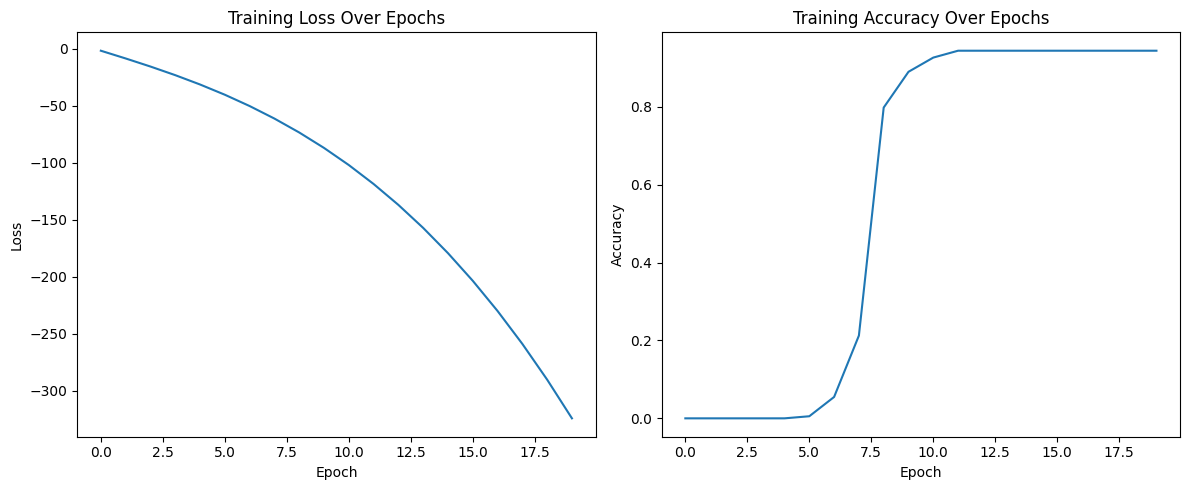

In [12]:
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss_history = []
accuracy_history = []

for epoch in range(20):

    model.train()

    out = model(features, adj)

    loss = F.binary_cross_entropy_with_logits(out, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Calculate training accuracy
    preds = (out > 0).float() # Apply sigmoid and threshold for multi-label classification
    # For accuracy and F1-score, we need to handle multi-label case.
    # Here, we'll use micro F1 for overall performance.
    # For accuracy, we can consider exact match or per-label accuracy.
    # Let's use accuracy_score from sklearn for per-sample accuracy (exact match).
    # For multi-label, a more common metric is F1 micro or macro.

    # Convert true labels to binary (since they are already one-hot encoded, threshold at 0.5 is fine)
    true_labels_binary = (labels > 0.5).cpu().numpy()
    pred_labels_binary = (preds > 0.5).cpu().numpy()

    # Calculate accuracy per epoch
    acc = accuracy_score(true_labels_binary, pred_labels_binary)

    loss_history.append(loss.item())
    accuracy_history.append(acc)

    print(f"Epoch: {epoch}, Loss: {loss.item():.4f}, Accuracy: {acc:.4f}")

# After training, evaluate final performance
model.eval()
with torch.no_grad():
    final_out = model(features, adj)
    final_preds = (final_out > 0).float()

    true_labels_final = (labels > 0.5).cpu().numpy()
    pred_labels_final = (final_preds > 0.5).cpu().numpy()

    final_accuracy = accuracy_score(true_labels_final, pred_labels_final)
    final_f1_micro = f1_score(true_labels_final, pred_labels_final, average='micro')
    final_f1_macro = f1_score(true_labels_final, pred_labels_final, average='macro')

    print(f"\nFinal Accuracy: {final_accuracy:.4f}")
    print(f"Final F1-score (Micro): {final_f1_micro:.4f}")
    print(f"Final F1-score (Macro): {final_f1_macro:.4f}")

# Plotting training loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

In [13]:
model_gcn = GraphSAGE_GCN(
    features.shape[1],
    128,
    labels.shape[1]
).to(device)


--- Training GraphSAGE_GCN ---
Epoch: 0, Loss: -0.2320, Accuracy: 0.0000
Epoch: 1, Loss: -3.2914, Accuracy: 0.0000
Epoch: 2, Loss: -6.3636, Accuracy: 0.0000
Epoch: 3, Loss: -9.4660, Accuracy: 0.0000
Epoch: 4, Loss: -12.6163, Accuracy: 0.0000
Epoch: 5, Loss: -15.8358, Accuracy: 0.0000
Epoch: 6, Loss: -19.1469, Accuracy: 0.0000
Epoch: 7, Loss: -22.5751, Accuracy: 0.0000
Epoch: 8, Loss: -26.1493, Accuracy: 0.0015
Epoch: 9, Loss: -29.9006, Accuracy: 0.0784
Epoch: 10, Loss: -33.8617, Accuracy: 0.9376
Epoch: 11, Loss: -38.0611, Accuracy: 0.9377
Epoch: 12, Loss: -42.5230, Accuracy: 0.9377
Epoch: 13, Loss: -47.2685, Accuracy: 0.9377
Epoch: 14, Loss: -52.3176, Accuracy: 0.9377
Epoch: 15, Loss: -57.6909, Accuracy: 0.9377
Epoch: 16, Loss: -63.4125, Accuracy: 0.9377
Epoch: 17, Loss: -69.5093, Accuracy: 0.9377
Epoch: 18, Loss: -76.0028, Accuracy: 0.9377
Epoch: 19, Loss: -82.9155, Accuracy: 0.9377

Final GCN Accuracy: 0.9377
Final GCN F1-score (Micro): 0.9700
Final GCN F1-score (Macro): 0.9700


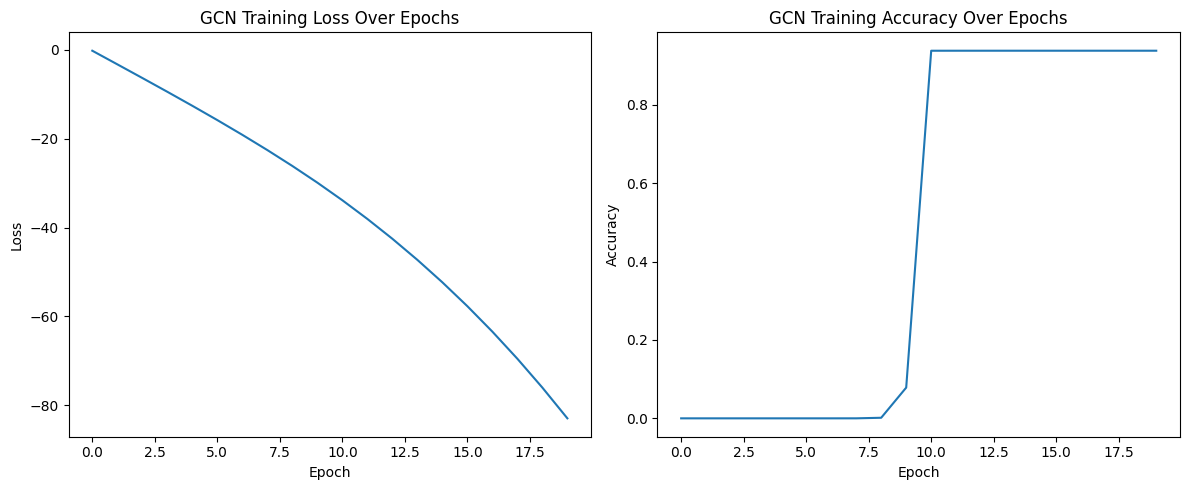

In [14]:
optimizer_gcn = torch.optim.Adam(model_gcn.parameters(), lr=0.001)

loss_history_gcn = []
accuracy_history_gcn = []

print("\n--- Training GraphSAGE_GCN ---")
for epoch in range(20):

    model_gcn.train()

    out_gcn = model_gcn(features, adj)

    loss_gcn = F.binary_cross_entropy_with_logits(out_gcn, labels)

    optimizer_gcn.zero_grad()
    loss_gcn.backward()
    optimizer_gcn.step()

    # Calculate training accuracy for GCN
    preds_gcn = (out_gcn > 0).float()
    true_labels_binary = (labels > 0.5).cpu().numpy()
    pred_labels_binary_gcn = (preds_gcn > 0.5).cpu().numpy()

    acc_gcn = accuracy_score(true_labels_binary, pred_labels_binary_gcn)

    loss_history_gcn.append(loss_gcn.item())
    accuracy_history_gcn.append(acc_gcn)

    print(f"Epoch: {epoch}, Loss: {loss_gcn.item():.4f}, Accuracy: {acc_gcn:.4f}")

# After training, evaluate final performance for GCN
model_gcn.eval()
with torch.no_grad():
    final_out_gcn = model_gcn(features, adj)
    final_preds_gcn = (final_out_gcn > 0).float()

    true_labels_final = (labels > 0.5).cpu().numpy()
    pred_labels_final_gcn = (final_preds_gcn > 0.5).cpu().numpy()

    final_accuracy_gcn = accuracy_score(true_labels_final, pred_labels_final_gcn)
    final_f1_micro_gcn = f1_score(true_labels_final, pred_labels_final_gcn, average='micro')
    final_f1_macro_gcn = f1_score(true_labels_final, pred_labels_final_gcn, average='macro')

    print(f"\nFinal GCN Accuracy: {final_accuracy_gcn:.4f}")
    print(f"Final GCN F1-score (Micro): {final_f1_micro_gcn:.4f}")
    print(f"Final GCN F1-score (Macro): {final_f1_macro_gcn:.4f}")

# Plotting training loss and accuracy for GCN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history_gcn)
plt.title('GCN Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(accuracy_history_gcn)
plt.title('GCN Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()